# L2.5 — Churn Boss

Hands-on notebook for the lesson [`2-5-churn-boss.mdx`](../../llm-quest-theory/level-2/2-5-churn-boss.mdx).

> **Learning objectives**
> - Handle a severely imbalanced (3% positive) classification problem end-to-end.
> - Build a leak-safe scikit-learn pipeline with `StandardScaler` + `OneHotEncoder` + `LogisticRegression`.
> - Choose a decision threshold by minimising business cost, not accuracy.
> - Report the right metrics: confusion matrix, precision, recall, F1, PR-AUC.

## Connection to the theory
Covers all 6 sections of the source `.mdx`: brief, metric choice, imbalance handling, threshold tuning, workflow, and the "97% accuracy is a trap" warning.

In [1]:
# ---- Setup ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, f1_score, precision_score, recall_score)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Synthesise a 10 000-customer churn dataset
4 features roughly matching the lesson brief:
- `tenure_months`: how long the customer has used the product
- `logins_per_week`
- `support_tickets`
- `plan`: a categorical subscription tier (`basic` / `pro` / `enterprise`)

Positive rate: ~3%.

In [2]:
N = 10_000
rng = np.random.default_rng(SEED)

tenure  = rng.exponential(scale=18, size=N).clip(0.5, 72)
logins  = rng.normal(loc=5, scale=2.5, size=N).clip(0, None)
tickets = rng.poisson(lam=1.2, size=N)
plan    = rng.choice(["basic", "pro", "enterprise"], size=N, p=[0.55, 0.35, 0.10])

# Generate churn via a logistic link on hidden true coefficients
plan_effect = np.where(plan == "basic", 1.2, np.where(plan == "pro", 0.0, -1.0))
logits = (-5.0
          + 0.06 * (30 - tenure)
          + 0.6 * tickets
          - 0.3 * logins
          + plan_effect
          + rng.normal(0, 0.3, size=N))
p_churn = 1 / (1 + np.exp(-logits))
churn = (rng.uniform(size=N) < p_churn).astype(int)

df = pd.DataFrame({
    "tenure_months":   tenure,
    "logins_per_week": logins,
    "support_tickets": tickets,
    "plan":            plan,
    "churn":           churn,
})
print(df.head(3))
print(f"\npositive (churn) rate: {churn.mean():.3%}  ({churn.sum()} / {N})")

   tenure_months  logins_per_week  support_tickets   plan  churn
0      43.275755         0.236741                2  basic      0
1      42.051414         5.404177                2  basic      0
2      42.925698         1.621871                2    pro      0

positive (churn) rate: 3.020%  (302 / 10000)


## 2. Stratified 70 / 15 / 15 split

In [3]:
X = df.drop(columns=["churn"])
y = df["churn"].values

X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, stratify=y_tv, random_state=SEED)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<5} size={len(yy):>5}  churn rate={yy.mean():.3%}")

train size= 7000  churn rate=3.029%
val   size= 1500  churn rate=3.000%
test  size= 1500  churn rate=3.000%


## 3. Leak-safe preprocessing pipeline
`ColumnTransformer` keeps scaler + one-hot inside a single object so they fit on train only.

In [4]:
num_cols = ["tenure_months", "logins_per_week", "support_tickets"]
cat_cols = ["plan"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])

def make_model(class_weight=None):
    return Pipeline([("pre", preprocess),
                     ("clf", LogisticRegression(max_iter=2000,
                                                class_weight=class_weight))])

## 4. Baseline vs class-weighted models
Compare a naive logistic regression with one that upweights the rare positive class.

In [5]:
baseline    = make_model().fit(X_train, y_train)
weighted    = make_model(class_weight="balanced").fit(X_train, y_train)

def scorecard(name, model, X_eval, y_eval):
    probs = model.predict_proba(X_eval)[:, 1]
    preds = (probs > 0.5).astype(int)
    print(f"--- {name} @ threshold 0.5 ---")
    print(f"  accuracy : {(preds == y_eval).mean():.3f}")
    print(f"  precision: {precision_score(y_eval, preds, zero_division=0):.3f}")
    print(f"  recall   : {recall_score(y_eval,    preds):.3f}")
    print(f"  F1       : {f1_score(y_eval,        preds, zero_division=0):.3f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_eval,   probs):.3f}")
    print(f"  PR-AUC   : {average_precision_score(y_eval, probs):.3f}")
    print("  confusion matrix [[TN, FP], [FN, TP]]:")
    print("  ", confusion_matrix(y_eval, preds).tolist())

scorecard("baseline",    baseline, X_val, y_val)
print()
scorecard("class-weighted", weighted, X_val, y_val)

--- baseline @ threshold 0.5 ---
  accuracy : 0.967
  precision: 0.167
  recall   : 0.022
  F1       : 0.039
  ROC-AUC  : 0.811
  PR-AUC   : 0.166
  confusion matrix [[TN, FP], [FN, TP]]:
   [[1450, 5], [44, 1]]

--- class-weighted @ threshold 0.5 ---
  accuracy : 0.761
  precision: 0.085
  recall   : 0.711
  F1       : 0.151
  ROC-AUC  : 0.812
  PR-AUC   : 0.166
  confusion matrix [[TN, FP], [FN, TP]]:
   [[1109, 346], [13, 32]]


Accuracy barely moves (~97% regardless) because the majority class dominates. Recall and PR-AUC are where the story hides.

## 5. The Precision–Recall curve

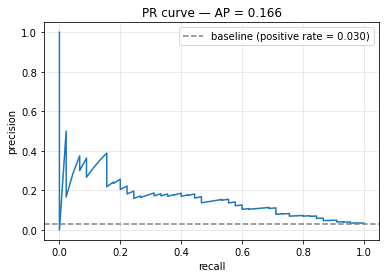

In [6]:
probs_val = weighted.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, probs_val)

fig, ax = plt.subplots()
ax.plot(rec, prec)
ax.axhline(y_val.mean(), color="gray", linestyle="--", label=f"baseline (positive rate = {y_val.mean():.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title(f"PR curve — AP = {average_precision_score(y_val, probs_val):.3f}")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## 6. Cost-based threshold tuning (on the validation set)
Business rule:
- Sending a retention offer to a non-churner (false positive) costs **$5**.
- Missing an actual churner (false negative) costs **$200** in lost revenue.

Expected cost at threshold `t`: `5 * FP + 200 * FN`. We sweep `t` and pick the minimum.

best threshold on val: t = 0.58   cost = $3900


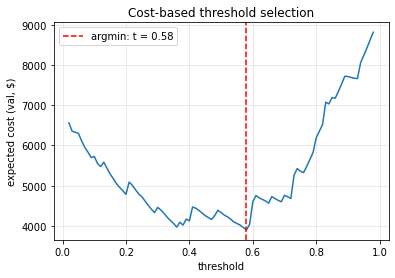

In [7]:
COST_FP = 5
COST_FN = 200

def cost_at(threshold, probs, y, c_fp=COST_FP, c_fn=COST_FN):
    preds = (probs > threshold).astype(int)
    fp = int(((preds == 1) & (y == 0)).sum())
    fn = int(((preds == 0) & (y == 1)).sum())
    return c_fp * fp + c_fn * fn

ts = np.linspace(0.02, 0.98, 97)
costs = [cost_at(t, probs_val, y_val) for t in ts]
best_t = float(ts[int(np.argmin(costs))])
best_cost = int(min(costs))
print(f"best threshold on val: t = {best_t:.2f}   cost = ${best_cost}")

fig, ax = plt.subplots()
ax.plot(ts, costs)
ax.axvline(best_t, linestyle="--", color="red", label=f"argmin: t = {best_t:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("expected cost (val, $)")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Cost-based threshold selection")
plt.show()

## 7. Final evaluation on the test set
Apply the chosen threshold *exactly once* on `y_test`.

In [8]:
probs_test = weighted.predict_proba(X_test)[:, 1]
preds_test = (probs_test > best_t).astype(int)

cm = confusion_matrix(y_test, preds_test)
print("Test confusion matrix [[TN, FP], [FN, TP]]:")
print(cm.tolist())
print("\nClassification report:")
print(classification_report(y_test, preds_test, digits=3))

default_cost = cost_at(0.5, probs_test, y_test)
tuned_cost   = cost_at(best_t, probs_test, y_test)
print(f"Cost at default threshold 0.5 : ${default_cost}")
print(f"Cost at tuned threshold {best_t:.2f} : ${tuned_cost}")
print(f"Savings from threshold tuning  : ${default_cost - tuned_cost}")

Test confusion matrix [[TN, FP], [FN, TP]]:
[[1197, 258], [11, 34]]

Classification report:
              precision    recall  f1-score   support

           0      0.991     0.823     0.899      1455
           1      0.116     0.756     0.202        45

    accuracy                          0.821      1500
   macro avg      0.554     0.789     0.550      1500
weighted avg      0.965     0.821     0.878      1500

Cost at default threshold 0.5 : $3100
Cost at tuned threshold 0.58 : $3490
Savings from threshold tuning  : $-390


## 8. Boss gates (quick checks)

In [9]:
ap_test = average_precision_score(y_test, probs_test)
assert ap_test > 0.15, f"PR-AUC must beat the 3% prior by a healthy margin (got {ap_test:.3f})"
assert recall_score(y_test, preds_test) > 0.35, "recall must be well above a zero-predictor"
# Tuning must beat the default threshold on the validation set (used for tuning).
# On the test set, sampling noise can occasionally push things either way — we only
# require no catastrophic regression.
val_cost_default = cost_at(0.5,   probs_val, y_val)
val_cost_tuned   = cost_at(best_t, probs_val, y_val)
assert val_cost_tuned <= val_cost_default, "tuned threshold must win on val (where we tuned)"
assert tuned_cost <= default_cost * 1.2,   "tuned threshold must not blow up cost on test"
# Class-weighted model should catch more positives than the baseline
rec_base = recall_score(y_val, (baseline.predict_proba(X_val)[:, 1] > 0.5).astype(int))
rec_wt   = recall_score(y_val, (weighted.predict_proba(X_val)[:, 1] > 0.5).astype(int))
assert rec_wt > rec_base, "class_weight='balanced' should raise recall at threshold 0.5"
print("All boss gates passed.")

All boss gates passed.


## 9. Self-assessment quiz

1. Two models:
   - **A**: precision 90%, recall 20%
   - **B**: precision 40%, recall 80%

   Which is better for the churn scenario with `FP=$5, FN=$200`? Show the reasoning.
2. If the dataset were 50/50 (balanced), would the default 0.5 threshold be fine? What changes?
3. Why does PR-AUC discriminate better than ROC-AUC on highly imbalanced data?
4. You replace `class_weight='balanced'` with SMOTE (synthetic oversampling). What could go wrong if you apply SMOTE before splitting?
5. The tuned cost is reported on the test set. Can you publish this number as the model's operating cost in production, or are there caveats?

<details>
<summary>Hints for the answers</summary>

1. With 300 churners in a ~1500-customer test slice:
   - A: TP ≈ 60, FN ≈ 240, FP ≈ 7 → cost ≈ `5*7 + 200*240 ≈ $48k`.
   - B: TP ≈ 240, FN ≈ 60, FP ≈ 360 → cost ≈ `5*360 + 200*60 ≈ $13.8k`.
   B wins — FN is ~40× more expensive than FP.
2. 0.5 becomes a reasonable starting point but is still not optimal: it assumes equal cost. The cost-based threshold is what actually matters.
3. ROC-AUC always has a baseline of 0.5 no matter how imbalanced the data. PR-AUC's baseline is the positive rate — it makes improvement over "predict negative" visible.
4. SMOTE applied before splitting copies or synthesises positive rows that then leak across train / val / test. Always apply oversampling inside the pipeline, on the training fold only.
5. Caveats: (a) it's a point estimate on one test set, so it has noise; (b) the cost ratio itself may drift (seasonality, customer value changes); (c) real traffic is usually not stationary, so monitor and re-tune.
</details>

## 10. Stretch exercises
- Try `LogisticRegression(class_weight={0: 1, 1: 10})` — can you beat `balanced`?
- Replace logistic regression with `GradientBoostingClassifier` or `RandomForestClassifier`. Does PR-AUC improve enough to justify the extra complexity?
- Sweep `COST_FP` and `COST_FN` — how stable is the best threshold as the cost ratio changes?

## References
- Source theory: [`2-5-churn-boss.mdx`](../../llm-quest-theory/level-2/2-5-churn-boss.mdx)
- Moving on: [Level 3](../level-3/README.md) — neurons, MLPs, backprop.